# Apprentissage non supervisé

Il y a trois grande catégorie dans l'apprentissage non supervisé :
- Le clustering
- La détection d'anomalie
- la réduction de la dimension.

## Qu'est-ce que l'apprentissage non supervisé 

L'apprentissage non supervisé est un apprentissage ou l'on donne à la machine uniquement des données X sans leur target y.

C'est donc la machine elle même qui va tenter de déduire les résultats à partir des données fournies.

## Clustering

Dans le cas du clustering la machin va par exemple regroupé les données celon une caractéristique qui les sépare. Par exemple le nombre de pattes d'un animal et/ou s'il a des ailes,  dans ce cas on se retrouverais par exemple avec les classes suivantes qui seraient déduite :
- Les animaux quadripède
- Les animaux bipède
- Les oiseau
- les insectes

Cette technique apporte beaucoup de possibilités : 
- segmentation de la clientel d'une entreprise
- classement de photos
- classement de documents
- faire du market research
- ...

Ici nous allons utiliser l'algorithme K-Mean Clustering pour faire ce type d'analyse.

In [253]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## K-Mean Clustering

Imaginons que nous voulons classé les données suivantes :

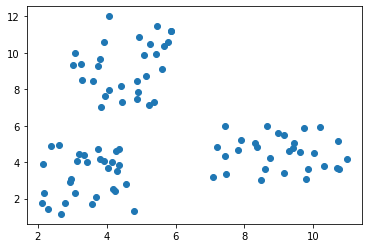

In [254]:
X1 = np.random.uniform(low=2, high=5, size=30)
y1 = np.random.uniform(low=1, high=5, size=30)

X2 = np.random.uniform(low=7, high=11, size=30)
y2 = np.random.uniform(low=3, high=6, size=30)

X3 = np.random.uniform(low=3, high=6, size=30)
y3 = np.random.uniform(low=7, high=12, size=30)

X = np.concatenate((X1, X2, X3), axis=None)
y = np.concatenate((y1, y2, y3), axis=None)

plt.scatter(X, y)

Ici on veut distingué trois groupes de données. La machine elle va d'abord positionner trois points (appelé K centroids) au hazard dans notre dataset

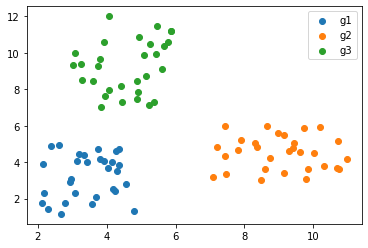

In [255]:
plt.scatter(X1, y1, label="g1")
plt.scatter(X2, y2, label="g2")
plt.scatter(X3, y3, label="g3")
plt.legend()

In [256]:
from sklearn.cluster import KMeans

X_val = np.insert(np.expand_dims(np.array(X), axis=1), 1, np.array(y), axis=1)

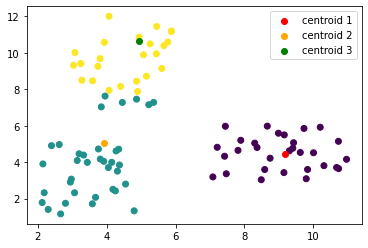

In [257]:
estimator = KMeans(
        n_clusters=3, # nombr de cluster à trouver
        init='random', # ici on va le laisser par défaut à k-means++
        random_state=2,
        max_iter=1, #nombre max d'itérations (on le laisse à sa valeur par défaut qui est 300)
        n_init=1) # nombre d'execution de l'algorithm (on le laisse à sa valeur par défaut qui est 10)
        
estimator.fit(X_val)

plt.scatter(X_val[:,0], X_val[:,1], c=estimator.labels_)
plt.scatter(estimator.cluster_centers_[0,0], estimator.cluster_centers_[0,1], c='r', label="centroid 1")
plt.scatter(estimator.cluster_centers_[1,0], estimator.cluster_centers_[1,1], c='orange', label="centroid 2")
plt.scatter(estimator.cluster_centers_[2,0], estimator.cluster_centers_[2,1], c='g', label="centroid 3")
plt.legend()

On affecte ensuite chaque point du dataset au centroid le plus proche.

Ensuite on place nos centroid au centre de ce groupe de points et on répète l'opération jusqu'à ce que nos centroid ne bougent plus.

C'est donc une algorithme qui travail en deux étapes : 
- Affcetation des points au centroid le plus proche 
- Déplacement du centroid à la moyenne de son cluster

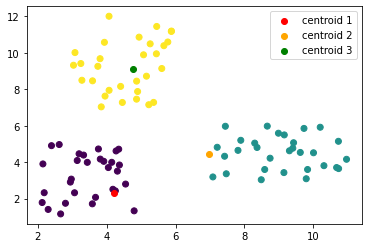

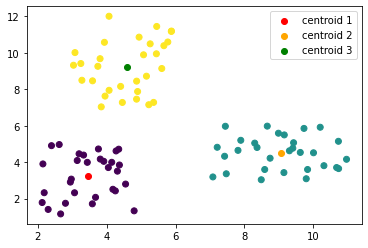

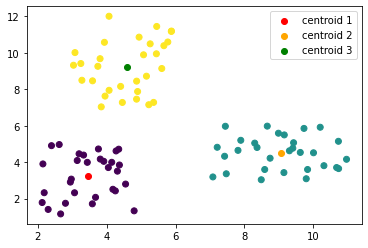

In [258]:
for i in range(1, 4):
    estimator = KMeans(
        n_clusters=3, # nombr de cluster à trouver
        init='random', # ici on va le laisser par défaut à k-means++
        random_state=4,
        max_iter=i, #nombre max d'itérations (on le laisse à sa valeur par défaut qui est 300)
        n_init=1) # nombre d'execution de l'algorithm (on le laisse à sa valeur par défaut qui est 10)
        
    estimator.fit(X_val)

    plt.scatter(X_val[:,0], X_val[:,1], c=estimator.labels_)
    plt.scatter(estimator.cluster_centers_[0,0], estimator.cluster_centers_[0,1], c='r', label="centroid 1")
    plt.scatter(estimator.cluster_centers_[1,0], estimator.cluster_centers_[1,1], c='orange', label="centroid 2")
    plt.scatter(estimator.cluster_centers_[2,0], estimator.cluster_centers_[2,1], c='g', label="centroid 3")
    plt.legend()
    plt.show()

Cette technique est bien mais il se peut qu'il y ai des erreurs par exemple un des centroid peut avoir été positionner à un endroit qui le centrera sur la moyenne de deux groupes n'ayant aucun rapport, et un groupe peut du coup se retrouver divisé en deux.

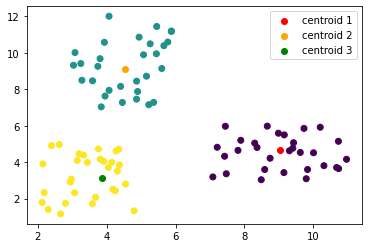

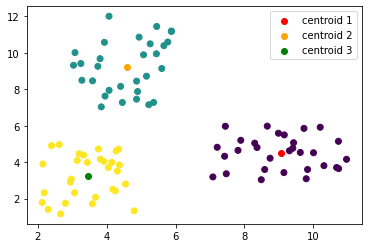

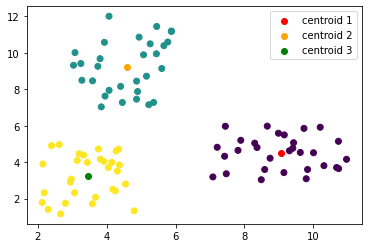

In [259]:
for i in range(1, 4):
    estimator = KMeans(
        n_clusters=3, # nombr de cluster à trouver
        init='random', # ici on va le laisser par défaut à k-means++
        random_state=1,
        max_iter=i, #nombre max d'itérations (on le laisse à sa valeur par défaut qui est 300)
        n_init=1) # nombre d'execution de l'algorithm (on le laisse à sa valeur par défaut qui est 10)
        
    estimator.fit(X_val)

    plt.scatter(X_val[:,0], X_val[:,1], c=estimator.labels_)
    plt.scatter(estimator.cluster_centers_[0,0], estimator.cluster_centers_[0,1], c='r', label="centroid 1")
    plt.scatter(estimator.cluster_centers_[1,0], estimator.cluster_centers_[1,1], c='orange', label="centroid 2")
    plt.scatter(estimator.cluster_centers_[2,0], estimator.cluster_centers_[2,1], c='g', label="centroid 3")
    plt.legend()
    plt.show()

Pour éviter ce soucis l'algorithme va procédé à plusieurs exécutions de l'algorithme en modifiant à chaque fois la position des centroids initial.

On prend ensuite la somme entre le points x et le centre de leur cluster µ et on retient la solution dont la sommes des distances est la plus petite.

Cet algorithme va donc tenter de réduire la variance des clusters.

number of executions : 1


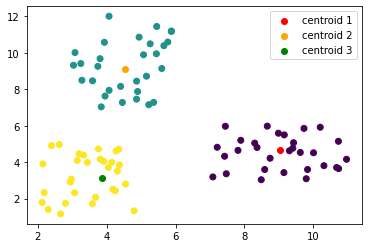

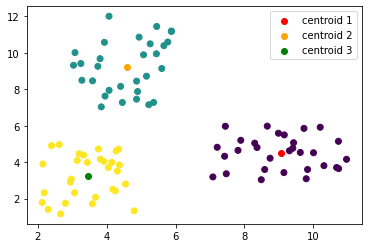

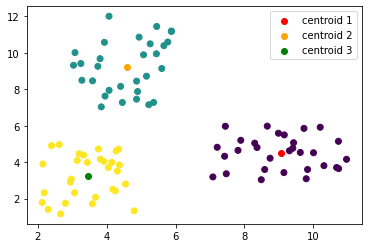

number of executions : 2


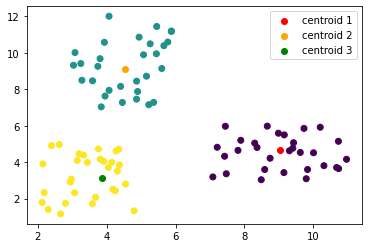

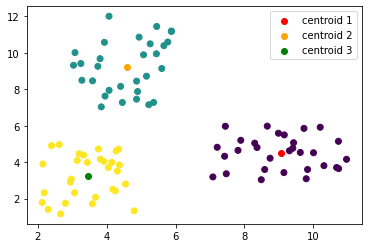

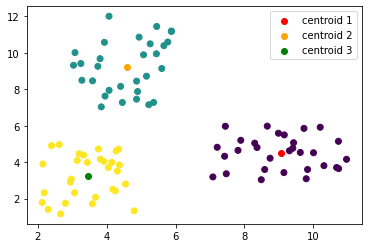

number of executions : 3


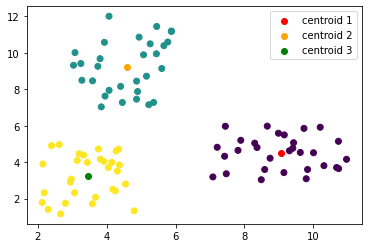

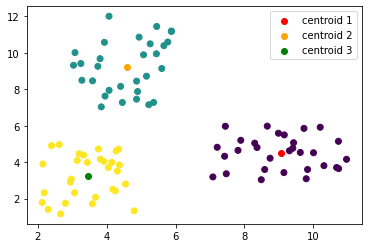

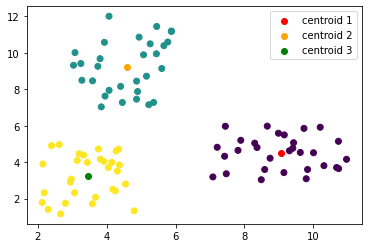

In [260]:
for j in range(1, 4):
    print(f'number of executions : {j}')
    for i in range(1, 4):
        estimator = KMeans(
            n_clusters=3, # nombr de cluster à trouver
            init='random', # ici on va le laisser par défaut à k-means++
            random_state=1,
            max_iter=i, #nombre max d'itérations (on le laisse à sa valeur par défaut qui est 300)
            n_init=j) # nombre d'execution de l'algorithm (on le laisse à sa valeur par défaut qui est 10)
            
        estimator.fit(X_val)

        plt.scatter(X_val[:,0], X_val[:,1], c=estimator.labels_)
        plt.scatter(estimator.cluster_centers_[0,0], estimator.cluster_centers_[0,1], c='r', label="centroid 1")
        plt.scatter(estimator.cluster_centers_[1,0], estimator.cluster_centers_[1,1], c='orange', label="centroid 2")
        plt.scatter(estimator.cluster_centers_[2,0], estimator.cluster_centers_[2,1], c='g', label="centroid 3")
        plt.legend()
        plt.show()

In [261]:
estimator = KMeans(
        n_clusters=3, # nombr de cluster à trouver
        init='k-means++', # ici on va le laisser par défaut à k-means++
        max_iter=300, #nombre max d'itérations (on le laisse à sa valeur par défaut qui est 300)
        n_init=10) # nombre d'execution de l'algorithm (on le laisse à sa valeur par défaut qui est 10)

## Le paramètre init

Par défaut c'est le K-Means++, c'est une algorithme qui consiste à placer les centroid sur des points éloigné des uns des autres de notre dataset.

C'est une très bonne méthode donc on n'y touchera que rarement, il en va de même avec les max_iter et le n_init.

In [262]:
estimator.fit(X_val)

KMeans(n_clusters=3)

In [263]:
estimator.labels_

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [264]:
estimator.predict(X_val)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

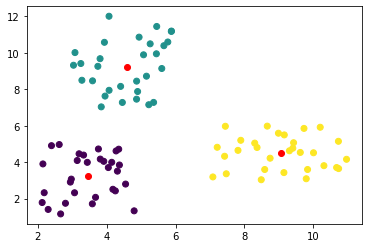

In [265]:
plt.scatter(X_val[:,0], X_val[:,1], c=estimator.labels_)
plt.scatter(estimator.cluster_centers_[:,0], estimator.cluster_centers_[:,1], c='r')

On peut aussi récupérer la valeur d'inertie ce qui nous donnera la somme des distances entre les points d'un cluster et le centroid :

number of executions : 1
inertia : 205.81391775319574


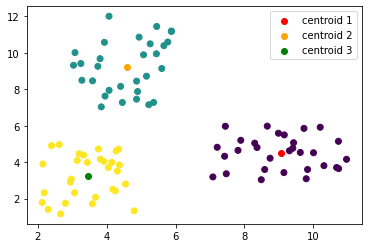

number of executions : 2
inertia : 205.81391775319574


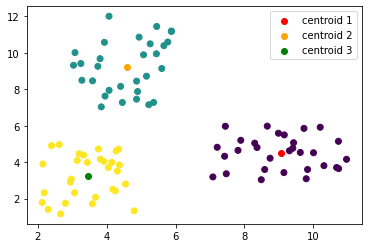

number of executions : 3
inertia : 205.81391775319574


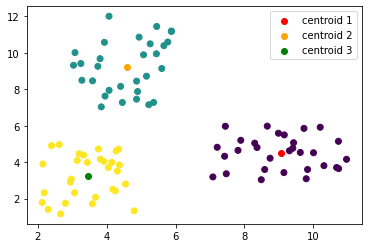

In [266]:
for j in range(1, 4):
    estimator = KMeans(
        n_clusters=3, # nombr de cluster à trouver
        init='random', # ici on va le laisser par défaut à k-means++
        random_state=1,
        max_iter=4, #nombre max d'itérations (on le laisse à sa valeur par défaut qui est 300)
        n_init=j) # nombre d'execution de l'algorithm (on le laisse à sa valeur par défaut qui est 10)
        
    estimator.fit(X_val)

    plt.scatter(X_val[:,0], X_val[:,1], c=estimator.labels_)
    plt.scatter(estimator.cluster_centers_[0,0], estimator.cluster_centers_[0,1], c='r', label="centroid 1")
    plt.scatter(estimator.cluster_centers_[1,0], estimator.cluster_centers_[1,1], c='orange', label="centroid 2")
    plt.scatter(estimator.cluster_centers_[2,0], estimator.cluster_centers_[2,1], c='g', label="centroid 3")
    plt.legend()
    print(f'number of executions : {j}')
    print(f'inertia : {estimator.inertia_}')
    plt.show()

Pour connaitre le cluster d'une nouvelle donnée la seule chose qui nous reste à faire est de passer la donnée à notre estimateur. Il va ensuite calculer la distance entre les centroids et notre nouvel valeur, et ensuite lui assigner le cluster appartenant au centroid le plus proche.

Le KMeans peut aussi être utiliser en tant que transformer et donc être utiliser pour créer de nouveaux groupes de variables dans nos données.

In [267]:
from sklearn.base import BaseEstimator, TransformerMixin

In [268]:
class KMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=8, random_state=1) -> None:
        self.n_clusters = n_clusters
        self.random_state = random_state
        self.cluster = KMeans(n_clusters=self.n_clusters, random_state=self.random_state)

    def fit(self, X, y=None, **args):
        self.cluster.fit(X)
        return self

    def transform(self, X, y=None, **args):
        clusters = self.cluster.predict(X)
        return clusters[:, None]

    def get_feature_names(self):
        return ['neighbourhood']

In [269]:
transformer = KMeanTransformer(20)
transformer.fit_transform(X_val)[:10]

array([[13],
       [15],
       [ 7],
       [15],
       [ 2],
       [ 7],
       [15],
       [12],
       [13],
       [12]], dtype=int32)

## Comment être sur de choisir le bon nombre de cluster pour notre algorithme ?

Dans le cas précédent c'étais simple, nous avions un dataset avec un nombre de cluster bien visible, mais qu'en est-il si notre dataset est beaucoup plus flou? Ou beaucoup trop grand et complexe que pour être analyser?

In [270]:
from sklearn.datasets import make_blobs

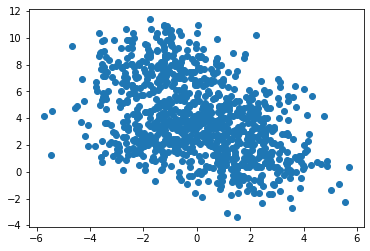

In [271]:
X, y = make_blobs(n_samples=1000, centers=4, cluster_std=1.4, random_state=0)
plt.scatter(X[:,0], X[:,1])

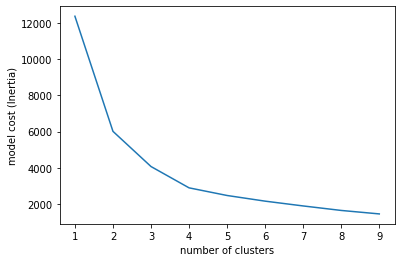

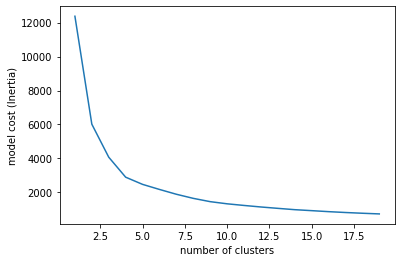

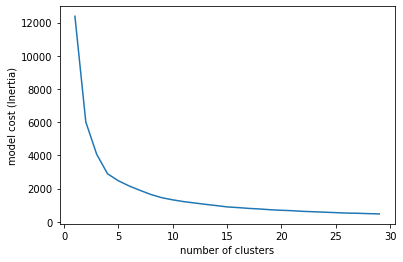

In [272]:
for i in range(10, 40, 10):
    inertias = []
    K_range = range(1, i)
    for k in K_range:
        model = KMeans(n_clusters=k).fit(X)
        inertias.append(model.inertia_)

    plt.figure()
    plt.plot(K_range, inertias)
    plt.xlabel('number of clusters')
    plt.ylabel('model cost (Inertia)')
    plt.show()

Le but ici est de détecter la zone de coude dans notre graphique. Celle-ci va nous dire le nombre optimal de cluster à avoir, car évidement au plus on monte dans les clusters au plus le modèle devient précis jusqu'au point ou notre nombre de cluster est égal au nombre de point ce qui aura un cout de 0. 

Le nombre optimal de cluster sera donc déterminer par le coude du graphique.

inertia : 2890.451965958376


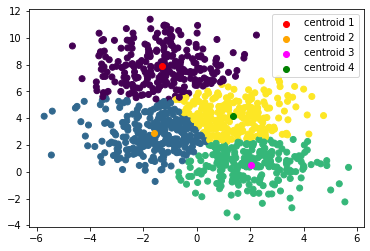

In [273]:
estimator = KMeans(n_clusters=4)
        
estimator.fit(X)

plt.scatter(X[:,0], X[:,1], c=estimator.labels_)
plt.scatter(estimator.cluster_centers_[0,0], estimator.cluster_centers_[0,1], c='r', label="centroid 1")
plt.scatter(estimator.cluster_centers_[1,0], estimator.cluster_centers_[1,1], c='orange', label="centroid 2")
plt.scatter(estimator.cluster_centers_[2,0], estimator.cluster_centers_[2,1], c='magenta', label="centroid 3")
plt.scatter(estimator.cluster_centers_[3,0], estimator.cluster_centers_[3,1], c='g', label="centroid 4")
plt.legend()
print(f'inertia : {estimator.inertia_}')
plt.show()

Il y a deux cas dans lesquels le KMeans n'obtiendra pas de bons résultats :

## Clusters Anisotropic

In [274]:
from sklearn import cluster, datasets

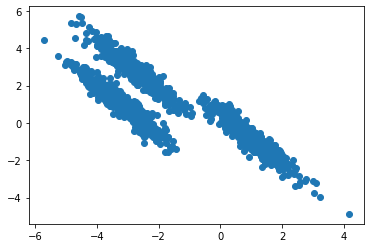

In [275]:
X, y = datasets.make_blobs(n_samples=1500, random_state=170)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
X = np.array((X_aniso))

plt.scatter(X[:,0], X[:,1])

inertia : 1743.1737162024738


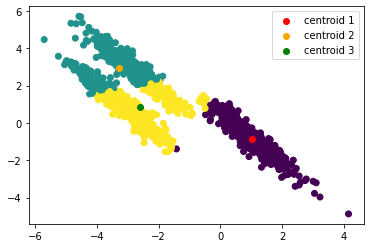

In [276]:
estimator = KMeans(n_clusters=3)
        
estimator.fit(X)

plt.scatter(X[:,0], X[:,1], c=estimator.labels_)
plt.scatter(estimator.cluster_centers_[0,0], estimator.cluster_centers_[0,1], c='r', label="centroid 1")
plt.scatter(estimator.cluster_centers_[1,0], estimator.cluster_centers_[1,1], c='orange', label="centroid 2")
plt.scatter(estimator.cluster_centers_[2,0], estimator.cluster_centers_[2,1], c='g', label="centroid 3")
plt.legend()
print(f'inertia : {estimator.inertia_}')
plt.show()

Dans ce cas ci le DBScan aura de meilleurs résultats.

In [277]:
from sklearn.cluster import DBSCAN

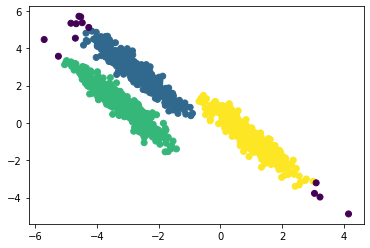

In [278]:
estimator = DBSCAN(eps=0.35)
        
estimator.fit(X)

plt.scatter(X[:,0], X[:,1], c=estimator.labels_)

plt.show()

Un problème similaire se posera dans des données contenant des clusters non convex :

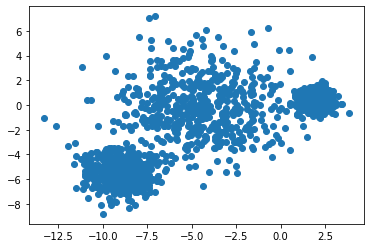

In [279]:
X, y = datasets.make_blobs(n_samples=1500,
                             cluster_std=[1.0, 2.5, 0.5],
                             random_state=170)

plt.scatter(X[:,0], X[:,1])

inertia : 5747.987366346283


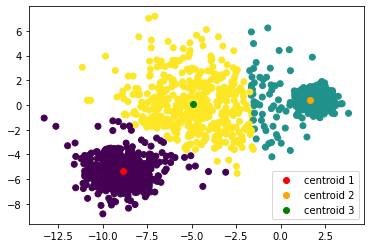

In [280]:
estimator = KMeans(n_clusters=3)
        
estimator.fit(X)

plt.scatter(X[:,0], X[:,1], c=estimator.labels_)
plt.scatter(estimator.cluster_centers_[0,0], estimator.cluster_centers_[0,1], c='r', label="centroid 1")
plt.scatter(estimator.cluster_centers_[1,0], estimator.cluster_centers_[1,1], c='orange', label="centroid 2")
plt.scatter(estimator.cluster_centers_[2,0], estimator.cluster_centers_[2,1], c='g', label="centroid 3")
plt.legend()
print(f'inertia : {estimator.inertia_}')
plt.show()

Dans ce cas ci ce sera AgglomerativeClustering qui sera le meilleur choix :

In [281]:
from sklearn.cluster import AgglomerativeClustering

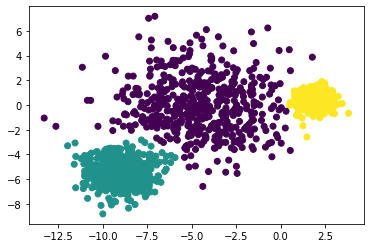

In [282]:
estimator = AgglomerativeClustering(n_clusters=3, linkage='ward')
        
estimator.fit(X)

plt.scatter(X[:,0], X[:,1], c=estimator.labels_)

plt.show()

Ces deux situations restant assez rare le KMeans restera l'outil de clustering le plus utilisé.

<a href="https://scikit-learn.org/stable/auto_examples/cluster/plot_linkage_comparison.html#sphx-glr-auto-examples-cluster-plot-linkage-comparison-py">Comparaison des algorithm</a>

## Détection d'anomalie

Ici la machine va analyser un échantillon de donnée et va tenter de trouver les différents échantillons dont les caractéristique X s'éloignent fort de celles des autres échantillons.

Ce genre d'analyse permet de faire :
- Des système de sécurité (trouver quelque chose d'inhabituel)
- Détection de hacking ou fraude banquaire (trouver une ou plusieurs opérations inhabituel réalisée)
- Défaillance de défaillance (trouver un ensemble de pièce défaillantes en sortie de production et leurs source)

Ici nous allons utiliser l'algorithme Isolation Forest pour faire ce genre d'analyse.

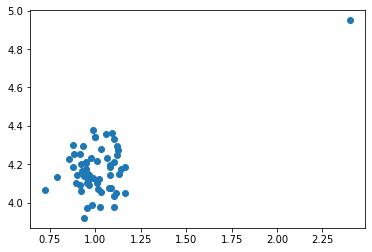

In [283]:
X, y = make_blobs(n_samples=60, centers=1, cluster_std=0.1, random_state=3)
X[-1,:] = np.array([2.40, 4.95])

plt.scatter(X[:,0], X[:, 1])

<AxesSubplot:ylabel='Density'>

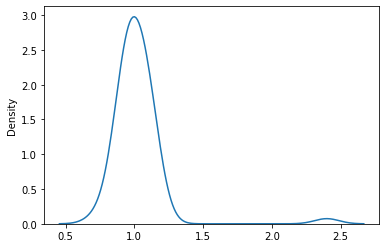

In [284]:
from scipy.stats import norm
sns.kdeplot(X[:,0])

<AxesSubplot:ylabel='Density'>

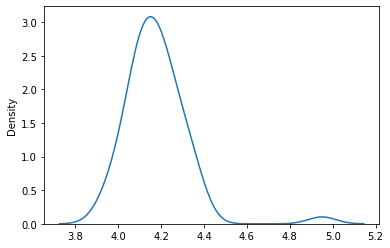

In [285]:
sns.kdeplot(X[:,1])

<AxesSubplot:>

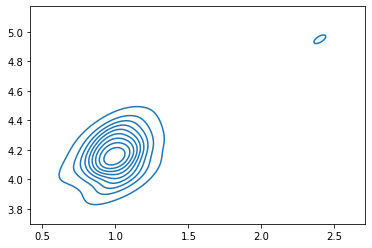

In [286]:
sns.kdeplot(x=X[:,0], y=X[:,1])

Ici nous allons utiliser la densité de probabilité (loi normale) pour calculer la probabilité d'existance d'un échantillon donné.

Quand cette probabilité est en dessous d'un certain seuil alors, l'échantillon est compté comme étant anormale.

Cette méthode est intéressente, mais ici nous allons utiliser l'Isolation forest, qui est une méthode plus moderne.

## Isolation Forest

Ici on va effectuer une série de split aléatoire, on competera ensuite le nombre de split qu'il nécéssaire pour effectuer  une isolation de nos échantillons.

Plus le nombre de splits est petit plus il y a de chance pour qu'il y ai une anomalie dans notre dataset.

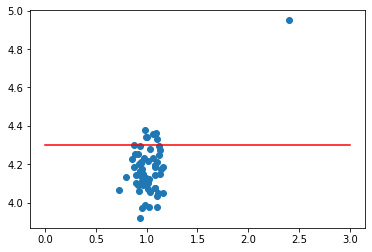

In [287]:
plt.scatter(X[:,0], X[:, 1])
plt.plot([0, 3], [4.3, 4.3], c='r')

On trace donc un trait au hazard pour séparer nos données.

On regarde ensuite si l'un de nos échantillons est isolé.

Ici ce n'est pas le cas.

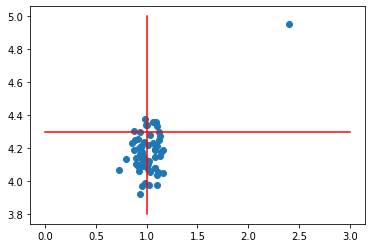

In [288]:
plt.scatter(X[:,0], X[:, 1])
plt.plot([0, 3], [4.3, 4.3], c='r')
plt.plot([1, 1], [3.8, 5.0], c='r')

On va donc continuer, et ce n'est toujours pas le cas nous n'avons pas isolé un échantillon.

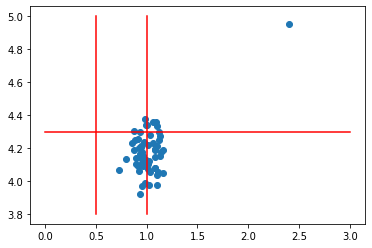

In [289]:
plt.scatter(X[:,0], X[:, 1])
plt.plot([0, 3], [4.3, 4.3], c='r')
plt.plot([1, 1], [3.8, 5.0], c='r')
plt.plot([0.5, 0.5], [3.8, 5.0], c='r')

On continue donc nos splits et encore une fois nous n'avons rien isoler.

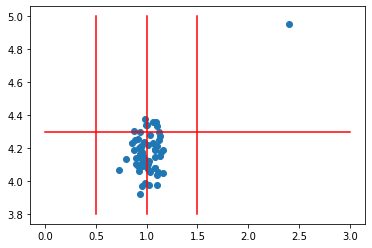

In [290]:
plt.scatter(X[:,0], X[:, 1])
plt.plot([0, 3], [4.3, 4.3], c='r')
plt.plot([1, 1], [3.8, 5.0], c='r')
plt.plot([0.5, 0.5], [3.8, 5.0], c='r')
plt.plot([1.5, 1.5], [3.8, 5.0], c='r')

Nous continuons de split et maintenant nous avons notre échantillon isolé.

Maintenant il est aussi possible, mais peu probable, qu'un autre échantillon soit isolé avant notre anomalie :

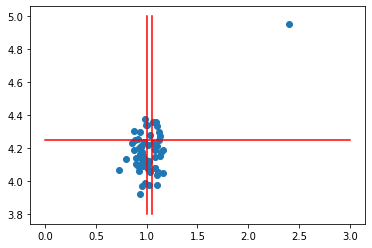

In [291]:
plt.scatter(X[:,0], X[:, 1])
plt.plot([0, 3], [4.25, 4.25], c='r')
plt.plot([1.0, 1.0], [3.8, 5.0], c='r')
plt.plot([1.05, 1.05], [3.8, 5.0], c='r')

Maintenant la fenêtre étant beaucoup plus petite il est extrêmement peu probable que cet échantillon soit isolé avant notre anomalie.

La solution pour contrer ce problème est similaire à celle que nous avons utilisé plus haut pour le KMeans, nous allons utiliser plusieurs estimateurs pour vérifier que nos splits aléatoire n'ont pas par malchance isolé un élément peu probable avant une anomalie.

Donc en utilisant l'ensemble des résultats celà nous permettera de disqualifier les résultats erroner.

C'est ce que l'on appel une technique d'ensemble.

L'isolation forest est enfait un enssemble de générateur de type arbre et donc les splits effectuer plutôt représente les embranchement des différents arbres.

In [292]:
from sklearn.ensemble import IsolationForest

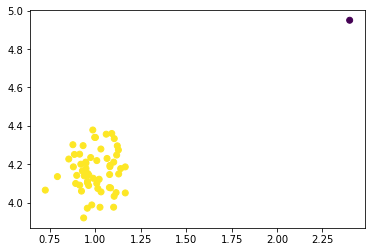

In [293]:
model = IsolationForest(contamination=0.01) # ici on va passer seulement le taux de contamination, ici j'ai choisi 1% de contamination.
model.fit(X)

plt.scatter(X[:,0], X[:, 1], c=model.predict(X))

Comme dit précédement ce modèle permet pas mal de chose, dont l'analyse de fraude banquaire. Mais il permet aussi de nettoyer un dataset comprenant des outliers.

## Netoyage d'outliers avec IsolationForest



In [294]:
from sklearn.datasets import load_digits

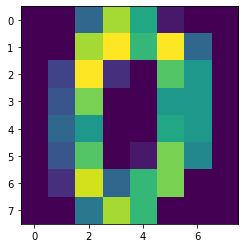

In [295]:
digits = load_digits()
images = digits.images
X = digits.data
y = digits.target

plt.imshow(images[0])

Ici notre but sera de netoyer le dataset des chiffres qui ne sont pas correctement écrit et qui peuvent impacter négativement notre modèle.

On va donc entrainer un model d'isolation forest, avec un taux de contamination de 3%, il faut tendre à garder ce taux de contamination bas, si on a plus de 5% de contamination dans ce cas c'est qu'il y a un soucis avec notre dataset.

On va donc entrainer le modèle, puis on observera ses prédictions, les prédictions seront soit 1 soit -1 (1 étant correcte et -1 étant fausse)

In [296]:
model = IsolationForest(random_state=0, contamination=0.03)
model.fit(X)
model.predict(X)

array([1, 1, 1, ..., 1, 1, 1])

In [297]:
np.unique(model.predict(X), return_counts=True)

(array([-1,  1]), array([  54, 1743]))

On va donc faire du boolean indexing.

Pour ce faire on crée une variable outliers qui va contenir nos outliers.

In [298]:
outliers = model.predict(X) == -1 

outliers

array([False, False, False, ..., False, False, False])

In [299]:
np.unique(outliers, return_counts=True)

(array([False,  True]), array([1743,   54]))

Maintenant on va pouvoir utiliser notre outliers pour récupérer uniquement les images contaminée, donc les anomalies de notre dataset.

In [300]:
images[outliers]

array([[[ 0.,  6., 13., ...,  8.,  1.,  0.],
        [ 0.,  8., 16., ..., 16.,  6.,  0.],
        [ 0.,  6., 16., ...,  4.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  9.,  0.,  0.],
        [ 0.,  1.,  8., ...,  3.,  0.,  0.],
        [ 0.,  4., 16., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ..., 15.,  4.,  0.],
        [ 0.,  0.,  0., ..., 16., 12.,  0.],
        [ 0.,  0.,  0., ..., 16., 12.,  0.],
        ...,
        [ 0.,  9., 16., ...,  1.,  0.,  0.],
        [ 0.,  3.,  8., ...,  9.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16., 12.,  0.]],

       [[ 0.,  6., 16., ..., 15., 10.,  0.],
        [ 0.,  9., 16., ...,  6.,  5.,  0.],
        [ 0., 12., 16., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  3., ...,  0.,  0.,  0.],
        [ 0.,  1.,  5., ...,  0.,  0.,  0.],
        [ 0.,  9., 16., ...,  0.,  0.,  0.]],

       ...,

       [[ 0.,  2., 12., ...,  0.,  0.,  0.],
        [ 0.,  7., 16., ...,  4.,  1.,  0.],
        [ 0.,  0., 13., ..., 15.,  1.,  0.

Et on pourra en observer une :

Text(0.5, 1.0, '9')

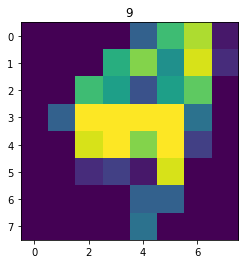

In [301]:
plt.imshow(images[outliers][16])
plt.title(y[outliers][16])

Ici on voit donc une des données contaminant notre dataset, en effet on peut voir qu'il s'agit sans doute d'un 9, ce qui est confirmer par notre title, mais ce n'est pas particulièrement clair au première abord.

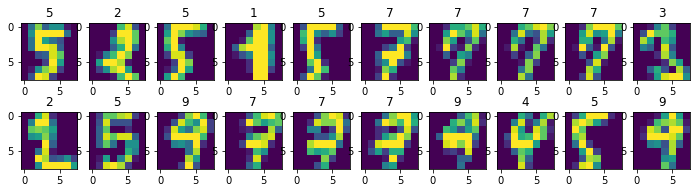

In [302]:
plt.figure(figsize=(12, 3))
for i in range(20):
  plt.subplot(2, 10, i+1)
  plt.imshow(images[outliers][i])
  plt.title(y[outliers][i])

Nous pouvons aussi utiliser le LocalOutlierFactor, celle-ci est moins avantageuse que la précédente sur des grand dataset, mais elle va utiliser l'algorithm du nearest neighbors.

<a href="https://scikit-learn.org/0.20/auto_examples/plot_anomaly_comparison.html">Comparaison des algorithm</a>

In [303]:
from sklearn.neighbors import LocalOutlierFactor

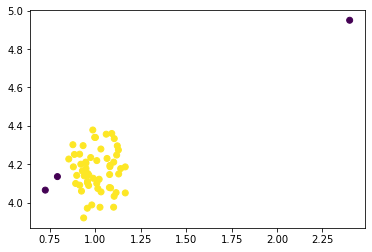

In [304]:
X1, y1 = make_blobs(n_samples=60, centers=1, cluster_std=0.1, random_state=3)
X1[-1,:] = np.array([2.40, 4.95])

lof = LocalOutlierFactor(n_neighbors=5, novelty=True)

lof.fit(X1)

plt.scatter(X1[:,0], X1[:, 1], c=lof.predict(X1))

## Réduction de la dimension

Ici la machine va apprendre à simplifier les données tout en conservant les informations principales.

Dans ce cas la machine va apprendre à projeter nos données dans un espace avec de plus petites dimensions.

L'algorithme qui nous permet de faire celà est l'analyse en composantes principales (PCA Principal Component Analysis).

Pour les applications :
- Simplifications des données superflue d'un dataset.
- Visualiser sur 2 ou 3 dimensions des espaces bien plus complexe.
- Accélérer l'apprentissage de la machine.
- Lute contre le fléau de la dimension (les risques d'overfitting lié au surplus de dimensions)

Le principe est ici de projeter nos données sur des axes appelés composantes principal, on cherchera ensuite à minimiser les distances entre nos points et leur projections.

Avec ce procédé on réduit la dimension de notre dataset tout en préservant au maximum la variance de nos données.

Pour ce qui est des mathématiques :
- On calcul d'abord la matrice de covariance des données
- On détermine les vecteurs propres à cette matrice (les composantes principales)
- On projette ensuite les données sur ces axes

In [305]:
from sklearn.decomposition import PCA

In [306]:
model = PCA(n_components=10)

model.fit_transform(X)

array([[ -1.25953259,  21.2749762 ,  -9.46317418, ...,   2.57974392,
         -0.59718533,   3.63466105],
       [  7.9577157 , -20.768872  ,   4.43912955, ...,  -4.59738349,
          3.57314983,  -1.04066042],
       [  6.99196768,  -9.95575519,   2.95934454, ..., -16.40524639,
          0.72384969,   4.23455513],
       ...,
       [ 10.80118168,  -6.96019609,   5.5996493 , ...,  -7.43729495,
         -3.94288273, -13.08518198],
       [ -4.87197128,  12.42420491, -10.17015709, ...,  -4.28647927,
          3.92923736, -13.12771346],
       [ -0.34440004,   6.36571626,  10.77427879, ...,   0.66646313,
         -4.09403004, -12.58461178]])

## Comment choisir le nombre de composantes ?

Il y a deux cas :
- On veut visualiser nos données dans un espace 2D ou 3D. Dans ce cas le n_components sera de 2 ou 3 en fonction du nombre de dimensions voulue.
- Compression de données, ceci permettera d'accélérer l'apprentissage de la machine pour un modèle de classification ou de régression. Dans ce second cas on désirera garder entre 95 et 99% de la variance de nos données. Au plus on réduit le nombr de composantes au plus notre dataset est compressé, et donc au moins la variance est conservée.

Text(0.5, 1.0, 'Compressed')

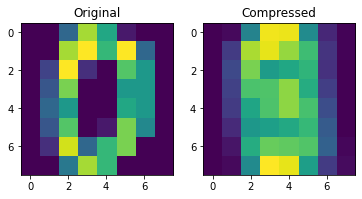

In [323]:
model = PCA(n_components=1)

X_compressed = model.fit_transform(X)
X_decompressed = model.inverse_transform(X_compressed)

plt.subplot(1, 2, 1)
plt.imshow(X[0,:].reshape((8,8)))
plt.title("Original")
plt.subplot(1, 2, 2)
plt.imshow(X_decompressed[0,:].reshape((8,8)))
plt.title("Compressed")

Ici on peu remarquer que la compression a annéhenti la variance de nos données. C'est pour celà qu'il est conseillé de garder de 95 à 99% de la variance de nos données, on verra comment faire cela un peu plus bas.

## Projection dans un espace 2D ou 3D

Ici nous allons projetter nos données dans un espace 2D :

In [324]:
X.shape

(1797, 64)

In [325]:
model = PCA(n_components=2)
X_reduced = model.fit_transform(X)
X_reduced.shape

(1797, 2)

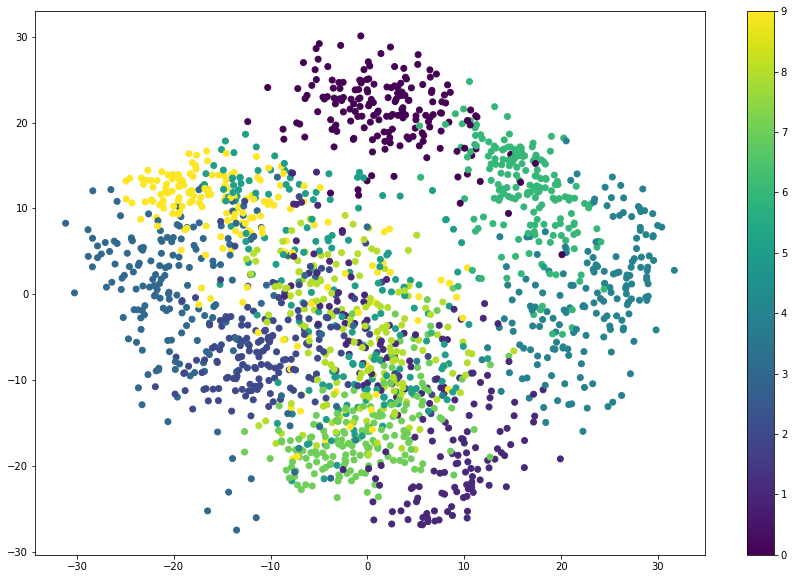

In [326]:
plt.figure(figsize=(15,10))
plt.scatter(X_reduced[:,0], X_reduced[:,1], c=y)
plt.colorbar()

Ici on va donc retrouver nos échantillons de notre dataset digits.

Nous avons en haut le 0, en bas le 1 (les formes étant fort différentes il est normal que les deux soient éloigné l'un de l'autre).

Ensuite nous avons le 9, 3 et 2 regroupé à gauche, ...

Pour rendre le tout plus lisible ce que nous pouvons faire c'est afficher directement du texte dans notre graphique :

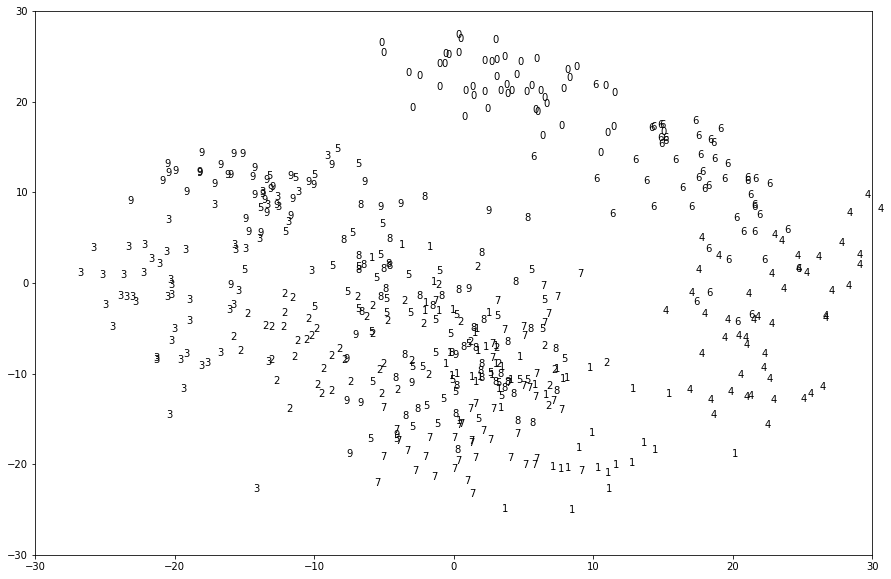

In [327]:
plt.figure(figsize=(15,10))
plt.xlim(-30, 30)
plt.ylim(-30, 30)

for i in range(500):
    plt.text(X_reduced[i,0], X_reduced[i, 1], str(y[i]))

Maintenant si nous voulons avoir une idée de ce que signifie les axes du graphique, il nous faudra analyser le contenu de chaque composantes :

In [328]:
model.components_

array([[ 3.90508344e-17, -1.73094601e-02, -2.23428790e-01,
        -1.35913323e-01, -3.30323607e-02, -9.66341891e-02,
        -8.32951128e-03,  2.26898924e-03, -3.20516052e-04,
        -1.19308866e-01, -2.44451665e-01,  1.48512659e-01,
        -4.67319660e-02, -2.17740759e-01, -1.48137243e-02,
         4.47779055e-03, -4.94135679e-05, -7.95418926e-02,
         8.33951233e-02,  2.15915262e-01, -1.72126795e-01,
        -1.63712016e-01,  2.86444723e-02,  4.23252072e-03,
         9.85488774e-05,  6.42319548e-02,  2.54093361e-01,
        -3.56771276e-02, -2.09462582e-01, -4.31310878e-02,
         5.13119168e-02,  2.13422807e-04,  0.00000000e+00,
         1.59950917e-01,  3.68690846e-01,  1.64406915e-01,
         8.52008216e-02,  3.72982010e-02,  2.15866685e-02,
         0.00000000e+00,  1.28865577e-03,  1.06945282e-01,
         3.03067445e-01,  2.47813009e-01,  2.09637360e-01,
         1.22324857e-02, -3.69459183e-02,  1.61484835e-03,
         6.93022939e-04, -8.35144815e-03, -5.58599286e-0

In [329]:
model.components_.shape

(2, 64)

Ici on se rend compte que chaque composante contient 64 valeurs. Celà signifie que chaque composantes est une combinaison linéaire des 64 variables de notre dataset.

## Compression de données

L'objectif est de réduire le nombre de variable en conservant entre 95 et 99% de la variance originale.

Pour faire celà nous allons commencer à entrainer notre modèle avec le même nombre de components que de colonne :

In [330]:
X.shape

(1797, 64)

In [331]:
model = PCA(n_components=64)
X_reduced = model.fit_transform(X)

On va ensuite observer le pourcentage de variance préservé par nos variables.

Pour ce faire nous allons utiliser :

In [332]:
model.explained_variance_ratio_

array([1.48905936e-01, 1.36187712e-01, 1.17945938e-01, 8.40997942e-02,
       5.78241466e-02, 4.91691032e-02, 4.31598701e-02, 3.66137258e-02,
       3.35324810e-02, 3.07880621e-02, 2.37234084e-02, 2.27269657e-02,
       1.82186331e-02, 1.77385494e-02, 1.46710109e-02, 1.40971560e-02,
       1.31858920e-02, 1.24813782e-02, 1.01771796e-02, 9.05617439e-03,
       8.89538461e-03, 7.97123157e-03, 7.67493255e-03, 7.22903569e-03,
       6.95888851e-03, 5.96081458e-03, 5.75614688e-03, 5.15157582e-03,
       4.89539777e-03, 4.28887968e-03, 3.73606048e-03, 3.53274223e-03,
       3.36683986e-03, 3.28029851e-03, 3.08320884e-03, 2.93778629e-03,
       2.56588609e-03, 2.27742397e-03, 2.22277922e-03, 2.11430393e-03,
       1.89909062e-03, 1.58652907e-03, 1.51159934e-03, 1.40578764e-03,
       1.16622290e-03, 1.07492521e-03, 9.64053065e-04, 7.74630271e-04,
       5.57211553e-04, 4.04330693e-04, 2.09916327e-04, 8.24797098e-05,
       5.25149980e-05, 5.05243719e-05, 3.29961363e-05, 1.24365445e-05,
      

Maintenant nous allons pouvoir faire la sommme cumulée de ces pourcentage de variances. Ce qui va nous permettre de voir à partir de quel moment la variance commence à baisser en dessous du seuil des 95% ou 99% en fonction de ce que l'on choisi.

In [333]:
np.cumsum(model.explained_variance_ratio_)

array([0.14890594, 0.28509365, 0.40303959, 0.48713938, 0.54496353,
       0.59413263, 0.6372925 , 0.67390623, 0.70743871, 0.73822677,
       0.76195018, 0.78467714, 0.80289578, 0.82063433, 0.83530534,
       0.84940249, 0.86258838, 0.87506976, 0.88524694, 0.89430312,
       0.9031985 , 0.91116973, 0.91884467, 0.9260737 , 0.93303259,
       0.9389934 , 0.94474955, 0.94990113, 0.95479652, 0.9590854 ,
       0.96282146, 0.96635421, 0.96972105, 0.97300135, 0.97608455,
       0.97902234, 0.98158823, 0.98386565, 0.98608843, 0.98820273,
       0.99010182, 0.99168835, 0.99319995, 0.99460574, 0.99577196,
       0.99684689, 0.99781094, 0.99858557, 0.99914278, 0.99954711,
       0.99975703, 0.99983951, 0.99989203, 0.99994255, 0.99997555,
       0.99998798, 0.99999503, 0.99999804, 0.99999911, 0.99999966,
       1.        , 1.        , 1.        , 1.        ])

On peut donc afficher tout ça dans un graphic :

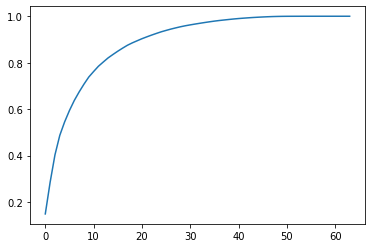

In [334]:
plt.plot(np.cumsum(model.explained_variance_ratio_))

Nous pouvons aussi chercher directement à quel moment la variance atteint le poucentage désiré :

In [335]:
np.argmax(np.cumsum(model.explained_variance_ratio_) > 0.99)

40

Ce qui nous indique que c'est à partir de la 40ème component principal que l'on atteint les 99% de la variance originale.

In [336]:
optimalCompnents = np.argmax(np.cumsum(model.explained_variance_ratio_) > 0.99)
model = PCA(n_components=optimalCompnents)

X_reduced = model.fit_transform(X)

X_decompressed = model.inverse_transform(X_reduced)

La fonction inverse_transform ne va pas récupérer les données originale mais repositionner les axes des composantes principales à l'endroit où elles ont étées calculées. C'est pour cette raison qu'il y a une perte de variance, car on ne récupèrera jamais les données originales.

Text(0.5, 1.0, 'Compressed')

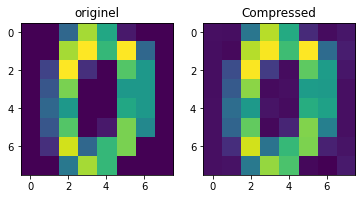

In [337]:
plt.subplot(1, 2, 1)
plt.imshow(X[0,:].reshape((8,8))) # le reshape sert à dire que l'on veut afficher nos données comme une image de 8px sur 8px
plt.title('originel')
plt.subplot(1, 2, 2)
plt.imshow(X_decompressed[0].reshape((8,8)))
plt.title('Compressed')

Une dernière chose assez pratique que l'on peut faire c'est que l'on peut rentrer dans n_components directement le pourcentage de variance que l'on souhaite garder :

Text(0.5, 1.0, 'Compressed')

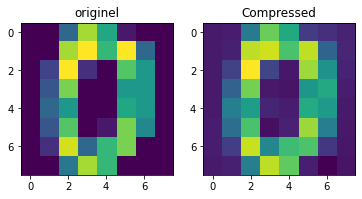

In [342]:
model = PCA(n_components=0.95)

X_reduced = model.fit_transform(X)

X_decompressed = model.inverse_transform(X_reduced)

plt.subplot(1, 2, 1)
plt.imshow(X[0,:].reshape((8,8))) # le reshape sert à dire que l'on veut afficher nos données comme une image de 8px sur 8px
plt.title('originel')
plt.subplot(1, 2, 2)
plt.imshow(X_decompressed[0].reshape((8,8)))
plt.title('Compressed')

Maintenant si l'ont veut savoir combien de components sont utilisé pour obtenir cette variance :

In [343]:
model.n_components_

29

## Informations importantes 

- Il faut TOUJOURS standardiser les données avant d'utiliser le PCA! La raison étant que les axes de l'analyse en composantes principal partent tous de l'origine de vos données. Donc il est impératif que vos données soient centrées et qu'elles aient une variance égale à 1. Donc il faudra utiliser le StandardScaler pour faciliter la projection de ces données sur ces axes.

- L'algorithme PCA est concue pour traiter des variables continues. Il arrive que l'on utilise le PCA pour compressé des données obtenue en OneHot, ça fonctionne mais ce n'est pas prévu pour.

- Cette algorithme n'est pas éfficace sur un dataset non linéaire.